In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nasal = pd.read_csv("Flow - 30-05-2024.txt", delimiter='\t')

In [3]:
print(nasal.head())

          Signal Type: Flow_TH_Type
0  Start Time: 5/30/2024 8:59:00 PM
1                   Sample Rate: 32
2                    Length: 875184
3                            Unit: 
4                             Data:


In [4]:
print(type(nasal))

<class 'pandas.core.frame.DataFrame'>


In [5]:
nasal1 = nasal.iloc[5: , :]

In [6]:
nasal1

,Signal Type: Flow_TH_Type
5,"30.05.2024 20:59:00,000; 120"
6,"30.05.2024 20:59:00,031; 120"
7,"30.05.2024 20:59:00,062; 84"
8,"30.05.2024 20:59:00,094; 91"
9,"30.05.2024 20:59:00,125; 97"
...,...
875184,"31.05.2024 04:34:49,344; -5"
875185,"31.05.2024 04:34:49,375; -5"
875186,"31.05.2024 04:34:49,406; -5"
875187,"31.05.2024 04:34:49,438; -5"


In [9]:
nasal1['Signal Type: Flow_TH_Type']

5         30.05.2024 20:59:00,000; 120
6         30.05.2024 20:59:00,031; 120
7          30.05.2024 20:59:00,062; 84
8          30.05.2024 20:59:00,094; 91
9          30.05.2024 20:59:00,125; 97
                      ...             
875184     31.05.2024 04:34:49,344; -5
875185     31.05.2024 04:34:49,375; -5
875186     31.05.2024 04:34:49,406; -5
875187     31.05.2024 04:34:49,438; -5
875188     31.05.2024 04:34:49,469; -5
Name: Signal Type: Flow_TH_Type, Length: 875184, dtype: object

In [10]:
nasal1['Time'] = nasal1['Signal Type: Flow_TH_Type'].str.split(';').str[0]
nasal1['Value'] = nasal1['Signal Type: Flow_TH_Type'].str.split(';').str[1]

C:\Users\UTSAV\AppData\Local\Temp\ipykernel_3256\3149737299.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nasal1['Time'] = nasal1['Signal Type: Flow_TH_Type'].str.split(';').str[0]
C:\Users\UTSAV\AppData\Local\Temp\ipykernel_3256\3149737299.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nasal1['Value'] = nasal1['Signal Type: Flow_TH_Type'].str.split(';').str[1]


In [11]:
nasal1

,Signal Type: Flow_TH_Type,Time,Value
5,"30.05.2024 20:59:00,000; 120","30.05.2024 20:59:00,000",120
6,"30.05.2024 20:59:00,031; 120","30.05.2024 20:59:00,031",120
7,"30.05.2024 20:59:00,062; 84","30.05.2024 20:59:00,062",84
8,"30.05.2024 20:59:00,094; 91","30.05.2024 20:59:00,094",91
9,"30.05.2024 20:59:00,125; 97","30.05.2024 20:59:00,125",97
...,...,...,...
875184,"31.05.2024 04:34:49,344; -5","31.05.2024 04:34:49,344",-5
875185,"31.05.2024 04:34:49,375; -5","31.05.2024 04:34:49,375",-5
875186,"31.05.2024 04:34:49,406; -5","31.05.2024 04:34:49,406",-5
875187,"31.05.2024 04:34:49,438; -5","31.05.2024 04:34:49,438",-5


In [12]:
flow = nasal1.copy()

In [13]:
flow.drop('Signal Type: Flow_TH_Type', axis=1, inplace=True)

In [14]:
flow = flow.set_index('Time')

In [15]:
flow.index = pd.to_datetime(flow.index, format="%d.%m.%Y %H:%M:%S,%f")

In [16]:
print(flow.index)

DatetimeIndex([       '2024-05-30 20:59:00', '2024-05-30 20:59:00.031000',
               '2024-05-30 20:59:00.062000', '2024-05-30 20:59:00.094000',
               '2024-05-30 20:59:00.125000', '2024-05-30 20:59:00.156000',
               '2024-05-30 20:59:00.188000', '2024-05-30 20:59:00.219000',
               '2024-05-30 20:59:00.250000', '2024-05-30 20:59:00.281000',
               ...
               '2024-05-31 04:34:49.188000', '2024-05-31 04:34:49.219000',
               '2024-05-31 04:34:49.250000', '2024-05-31 04:34:49.281000',
               '2024-05-31 04:34:49.313000', '2024-05-31 04:34:49.344000',
               '2024-05-31 04:34:49.375000', '2024-05-31 04:34:49.406000',
               '2024-05-31 04:34:49.438000', '2024-05-31 04:34:49.469000'],
              dtype='datetime64[ns]', name='Time', length=875184, freq=None)


In [17]:
flow['Value'] = pd.to_numeric(flow['Value'].astype(str).str.strip(), errors='coerce')
flow_macro = flow.resample('1s').median(numeric_only=True)

In [18]:
flow_macro

,Value
Time,
2024-05-30 20:59:00,90.0
2024-05-30 20:59:01,-83.0
2024-05-30 20:59:02,29.0
2024-05-30 20:59:03,81.5
2024-05-30 20:59:04,-102.0
...,...
2024-05-31 04:34:45,-4.0
2024-05-31 04:34:46,-2.0
2024-05-31 04:34:47,1.0


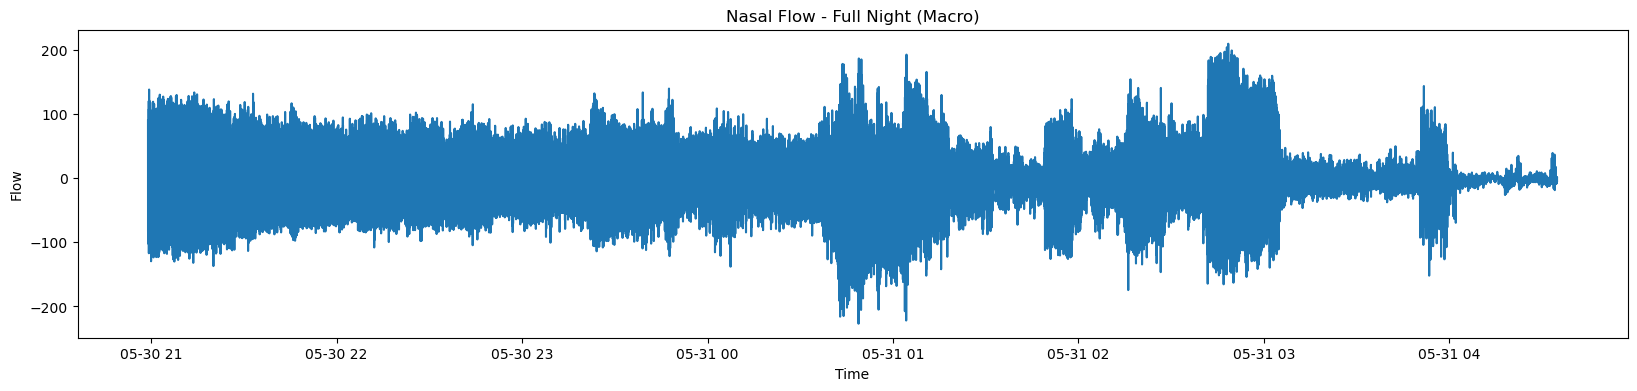

In [19]:
plt.figure(figsize=(20,4))
x = flow_macro.index
y = flow_macro['Value']
plt.plot(x, y)
plt.title("Nasal Flow - Full Night (Macro)")
plt.xlabel("Time")
plt.ylabel("Flow")
plt.show()

In [20]:
flow_macro2 = flow.resample('2s').median(numeric_only=True)

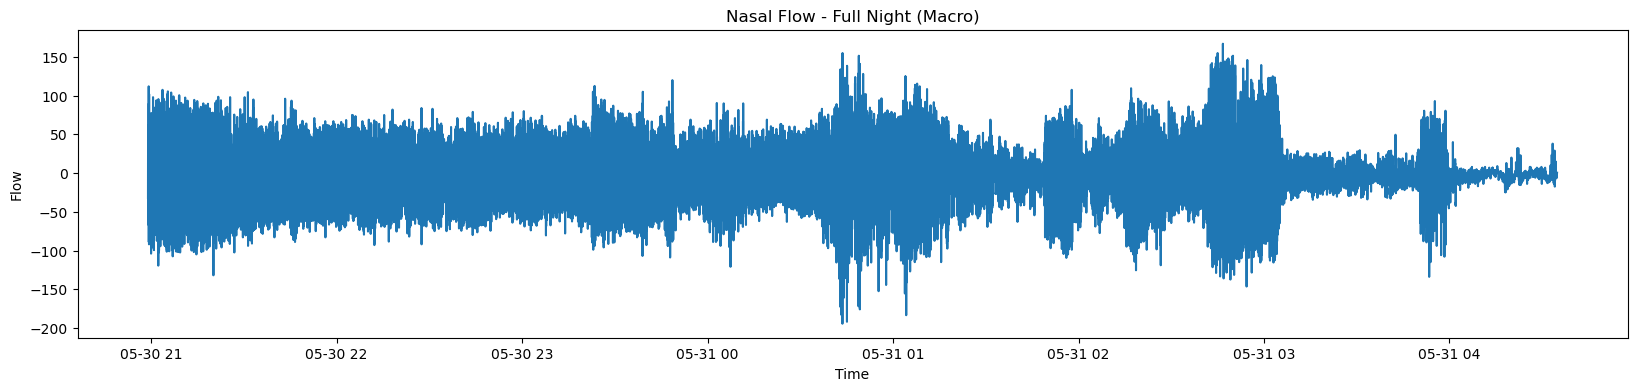

In [21]:
plt.figure(figsize=(20,4))
x = flow_macro2.index
y = flow_macro2['Value']
plt.plot(x, y)
plt.title("Nasal Flow - Full Night (Macro)")
plt.xlabel("Time")
plt.ylabel("Flow")
plt.show()

In [23]:
start_time = flow.index[0]

In [40]:
end_time = start_time + pd.Timedelta(minutes=1)

In [41]:
segment = flow.loc[start_time:end_time]

In [42]:
print(len(segment))

1921


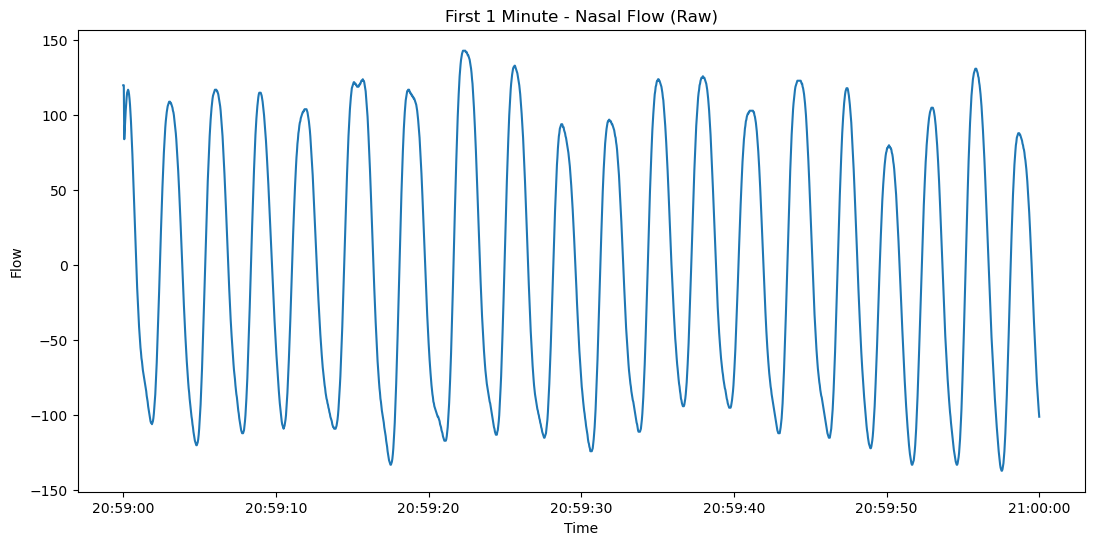

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13,6))
plt.plot(segment.index, segment['Value'])
plt.title("First 1 Minute - Nasal Flow (Raw)")
plt.xlabel("Time")
plt.ylabel("Flow")
plt.show()